In [12]:
# SEA-AD single cell Data presentation
This notebook will display information about the SEA-AD datasets, and which QCs have been performed.
SEA-AD currently contained 2 datasets : single nuclei data from DLPFC and from MTG region.

The datasets have been downloaded from [aws](https://sea-ad-single-cell-profiling.s3.amazonaws.com) (see [01-get_seaad_data.R](../scripts/01-get_seaad_data.R))  
The data and metadata was stored in a same .h5ad file (anndata/python based single cell object).  
For each dataset, Cell metadata (containing both donor and cell level information) have been extracted from the objects and save in csv in `outputs/01-SEAAD_data/[BrainRegion]/all_final_RNAseq_nuclei_metadata.csv.gz` (see [01Ai-extract_metadata.py](../singlecell-brain/scripts/01Ai-extract_metadata.py))
Then, data summary and QC have been done in [01D-SEA-AD_QC.R](../scripts/01D-SEA-AD_QC.R)
Sample level information have been extracted in  `outputs/01-SEAAD_data/[BrainRegion]/DLPFC/all_final_RNAseq_nuclei_sample_level_metadata.csv.gz`   
Cell type level information (%mito, cell type proportion ...) have been extracted from the cell level in `outputs/01-SEAAD_data/[BrainRegion]/all_final_RNAseq_nuclei_main_cell_type_level_metadata.csv.gz`

In this notebook, I will present these data summary and the preprocessing/formating perform for the DLPFC dataset, but the same apply for MTG and can be found in [01D-SEA-AD_QC.R](../scripts/01D-SEA-AD_QC.R)

## Get a common cell type annotation 
SEA-AD data have already be annotated for cell types and stored in the cell level metadata. 
Here we will first harmonize this annotation to be easily integrated with others dataset. SEA-AD from the Allen institute which have created the [Allen Brain map](https://portal.brain-map.org/) subdivize Excitatory and Inhibitory neurons according the brain layers from which they come from.
We will create a `cell_type` annotation containing these different cell types annotation, but also a `main_cell_type` containing only the main category used in most of the study

# SEA-AD single cell Data presentation
This notebook will display information about the SEA-AD datasets, and which QCs have been performed.
SEA-AD currently contained 2 datasets : single nuclei data from DLPFC and from MTG region.

The datasets have been downloaded from [aws](https://sea-ad-single-cell-profiling.s3.amazonaws.com) (see [01-get_seaad_data.R](../scripts/01-get_seaad_data.R))  
The data and metadata was stored in a same .h5ad file (anndata/python based single cell object).  
For each dataset, Cell metadata (containing both donor and cell level information) have been extracted from the objects and save in csv in `outputs/01-SEAAD_data/[BrainRegion]/all_final_RNAseq_nuclei_metadata.csv.gz` (see [01Ai-extract_metadata.py](../singlecell-brain/scripts/01Ai-extract_metadata.py))
Then, data summary and QC have been done in [01D-SEA-AD_QC.R](../scripts/01D-SEA-AD_QC.R)
Sample level information have been extracted in  `outputs/01-SEAAD_data/[BrainRegion]/DLPFC/all_final_RNAseq_nuclei_sample_level_metadata.csv.gz`   
Cell type level information (%mito, cell type proportion ...) have been extracted from the cell level in `outputs/01-SEAAD_data/[BrainRegion]/all_final_RNAseq_nuclei_main_cell_type_level_metadata.csv.gz`

In this notebook, I will present these data summary and the preprocessing/formating perform for the DLPFC dataset, but the same apply for MTG and can be found in [01D-SEA-AD_QC.R](../scripts/01D-SEA-AD_QC.R)

## Get a common cell type annotation 
SEA-AD data have already be annotated for cell types and stored in the cell level metadata. 
Here we will first harmonize this annotation to be easily integrated with others dataset. SEA-AD from the Allen institute which have created the [Allen Brain map](https://portal.brain-map.org/) subdivize Excitatory and Inhibitory neurons according the brain layers from which they come from.
We will create a `cell_type` annotation containing these different cell types annotation, but also a `main_cell_type` containing only the main category used in most of the study


In [1]:
#.libPaths(c('/projectnb/tcwlab/LabMember/adpelle1/micromamba/envs/pisces-rabbit/lib/R/library'))
.libPaths()
sessionInfo()


[1] "/projectnb/tcwlab/LabMember/adpelle1/R/x86_64-pc-linux-gnu-library/4.2"
[2] "/projectnb/tcwlab-adsp/member/adpelle1/Rlib"                           
[3] "/share/pkg.7/r/4.2.1/install/lib64/R/library"

R version 4.2.1 (2022-06-23)
Platform: x86_64-pc-linux-gnu (64-bit)

Matrix products: default
BLAS:   /share/pkg.7/r/4.2.1/install/lib64/R/lib/libRblas.so
LAPACK: /share/pkg.7/r/4.2.1/install/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] getPass_0.2-2        fansi_1.0.4          crayon_1.5.2        
 [4] digest_0.6.33        utf8_1.2.3           IRdisplay_1.1.0.9000
 [7] repr_1.1.6.9000      lifecycle_1.0.4      jsonlite_1.8.7      
[10] evaluate_0.21        pillar_1.9.0         rlang_1.1.1         
[13] cli_3.6.1            uuid_1.1-0           vctrs_0.6.3         
[16] IRkernel_1.3.2.9000  tool

In [ ]:
library(data.table)
library(stringr)
library(ggplot2) #I had to reinstall ragg in pisces-rabbit environment to make it work

In [3]:
mtd<-fread('../outputs/01-SEAAD_data/DLPFC/all_final_RNAseq_nuclei_metadata.csv.gz')
mtd
mtd[,cell_type:=ifelse(str_detect(Class,'Glut'),paste0('Exc_',Subclass),
                       ifelse(str_detect(Class,'GABA'),paste0('Inh_',Subclass),Subclass))]
unique(mtd$cell_type)
mtd[,main_cell_type:=str_extract(cell_type,'Oligo|Exc|Inh|Astro|Mic|Endo|VLMC|OPC')]
mtd[,main_cell_type:=factor(main_cell_type,levels = c('Exc','Inh','Oligo','Astro','OPC','Mic','VLMC','Endo'))]


Warning message in require_bit64_if_needed(ans):
“Some columns are type 'integer64' but package bit64 is not installed. Those columns will print as strange looking floating point data. There is no need to reload the data. Simply install.packages('bit64') to obtain the integer64 print method and print the data again.”


Donor.ID,exp_component_name,sample_id,Neurotypical.reference,Organism,Brain.Region,Sex,Gender,Age.at.Death,Race..choice.White.,⋯,avg.pct.mt.ct,n.cells,pct.ct,n.ct,n.ct.all,cell_prop_dev_pc1,outlier.cellular.status,outlier.cellprop,outlier,original_cell_type_name
<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>
H18.30.002,TCGAAGTGTTACACAC-L8TX_200107_01_A10-1003930257,TCGAAGTGTTACACAC-L8TX_200107_01_A10,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0027225655,28629,0.565440637,16188,660751,0.3070132,FALSE,FALSE,TRUE,L6b
H18.30.002,GGAAGTGGTTATCCAG-L8TX_200107_01_A10-1003930257,GGAAGTGGTTATCCAG-L8TX_200107_01_A10,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0013228314,28629,0.024380873,698,29041,0.3070132,FALSE,FALSE,TRUE,OPC
H18.30.002,CATCCACTCGCGGTAC-L8TX_200114_01_B11-1027251105,CATCCACTCGCGGTAC-L8TX_200114_01_B11,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0027225655,28629,0.565440637,16188,660751,0.3070132,FALSE,FALSE,TRUE,L4_IT
H18.30.002,TGAGTCATCTCCCATG-L8TX_200107_01_H09-1003930255,TGAGTCATCTCCCATG-L8TX_200107_01_H09,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0027225655,28629,0.565440637,16188,660751,0.3070132,FALSE,FALSE,TRUE,L2-3_IT
H18.30.002,GTGCGTGTCGCCTTTG-L8TX_200107_01_G09-1002609411,GTGCGTGTCGCCTTTG-L8TX_200107_01_G09,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0027225655,28629,0.565440637,16188,660751,0.3070132,FALSE,FALSE,TRUE,L6_IT
H18.30.002,AAAGGTAGTGTCTAAC-L8TX_200107_01_A10-1003930257,AAAGGTAGTGTCTAAC-L8TX_200107_01_A10,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0063779180,28629,0.306332740,8770,422449,0.3070132,FALSE,FALSE,TRUE,Pvalb
H18.30.002,TCAATTCTCGGTAACT-L8TX_200107_01_G09-1002609411,TCAATTCTCGGTAACT-L8TX_200107_01_G09,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0063779180,28629,0.306332740,8770,422449,0.3070132,FALSE,FALSE,TRUE,Pvalb
H18.30.002,TAGATCGAGAGGATCC-L8TX_200107_01_G09-1002609411,TAGATCGAGAGGATCC-L8TX_200107_01_G09,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0063779180,28629,0.306332740,8770,422449,0.3070132,FALSE,FALSE,TRUE,Pvalb
H18.30.002,TATGTTCGTAGATCCT-L8TX_200107_01_H09-1003930255,TATGTTCGTAGATCCT-L8TX_200107_01_H09,TRUE,human,Human DFC_all_layers,Male,Male,50,Reference,⋯,0.0027225655,28629,0.565440637,16188,660751,0.3070132,FALSE,FALSE,TRUE,L5-6_NP


[1] "Exc_L6b"         "OPC"             "Exc_L4 IT"       "Exc_L2/3 IT"    
 [5] "Exc_L6 IT"       "Inh_Pvalb"       "Exc_L5/6 NP"     "Inh_Sncg"       
 [9] "Endothelial"     "Inh_Lamp5"       "Astrocyte"       "Exc_L5 IT"      
[13] "Inh_Sst"         "Oligodendrocyte" "Exc_L6 CT"       "Inh_Vip"        
[17] "Microglia-PVM"   "Inh_Chandelier"  "Exc_L5 ET"       "Exc_L6 IT Car3" 
[21] "Inh_Pax6"        "Inh_Lamp5 Lhx6"  "Inh_Sst Chodl"   "VLMC"

For convenience manipulating it in R, we convert all columns names to remove any space on it (using `make.names` function)

In [4]:
#convert  column name to remove space
var_names<-colnames(mtd)
setnames(mtd,var_names,make.names(var_names))


In [5]:
## Assess Clinical Traits Information 
We will check available clinical/metadata and flag as outliers : 
    1. donors with missing dementia/cognitivw status,
    2. donors with ethnicity represented in <5 people,
    3. outlier in term of age, or PMI ( boxplot + visual inspection)
    4. donors with an abmormal CellType distribution or %mitochondrial

## Assess Clinical Traits Information 
We will check available clinical/metadata and flag as outliers : 
    1. donors with missing dementia/cognitivw status,
    2. donors with ethnicity represented in <5 people,
    3. outlier in term of age, or PMI ( boxplot + visual inspection)
    4. donors with an abmormal CellType distribution or %mitochondrial


In [6]:
### Cognitive status


### Cognitive status



 29  42  50  68  69  70  72  75  77  78  80  81  82  83  84  85  86  87  88  89 
  1   1   1   1   1   1   1   2   1   1   2   3   4   3   2   1   3   2   4   3 
90+ 
 45 


   Dementia No dementia   Reference 
         39          41           3 

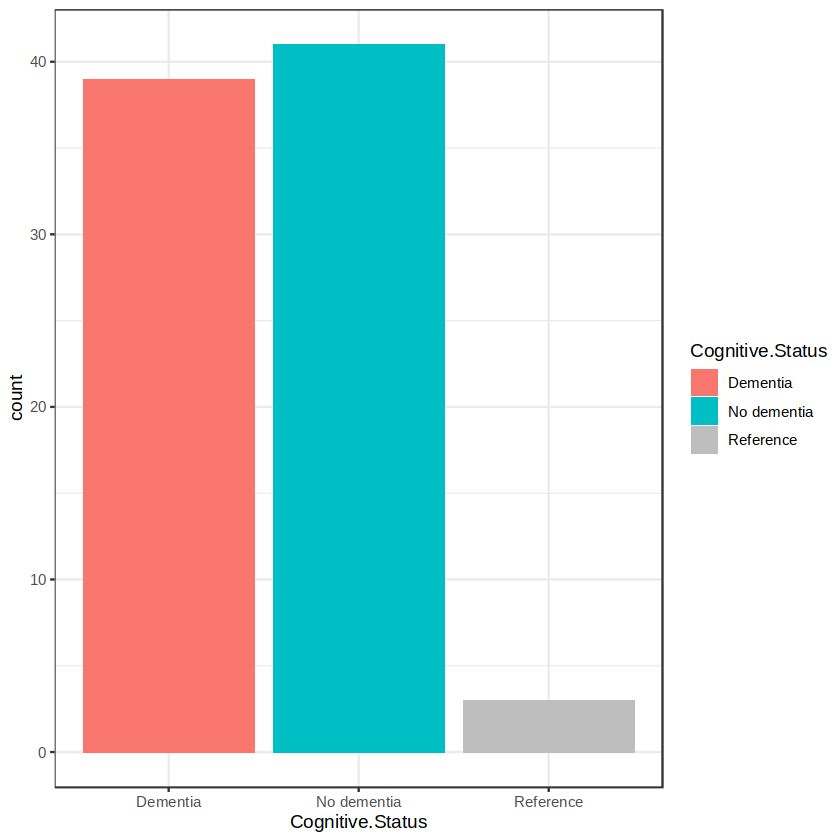

In [7]:
mts<-unique(mtd,by=c('Donor.ID'))
#check Age, PMI, ethnicity
#flag missing info
table(mts$Age.at.Death)
table(mts$Cognitive.Status)
ggplot(mts)+geom_bar(aes(x=Cognitive.Status,fill=Cognitive.Status))+theme_bw( )+scale_fill_manual(values=c(scales::hue_pal()(2),'grey'))
 #missing cognitive status
mts[,missing.cognitive.status:=Cognitive.Status=='Reference']


In [8]:
`Reference` donors do not have clinical/cognitive data, so will be excluded from analyis

`Reference` donors do not have clinical/cognitive data, so will be excluded from analyis


In [9]:
### APOE4 genotype


### APOE4 genotype



 N  Y 
57 23 

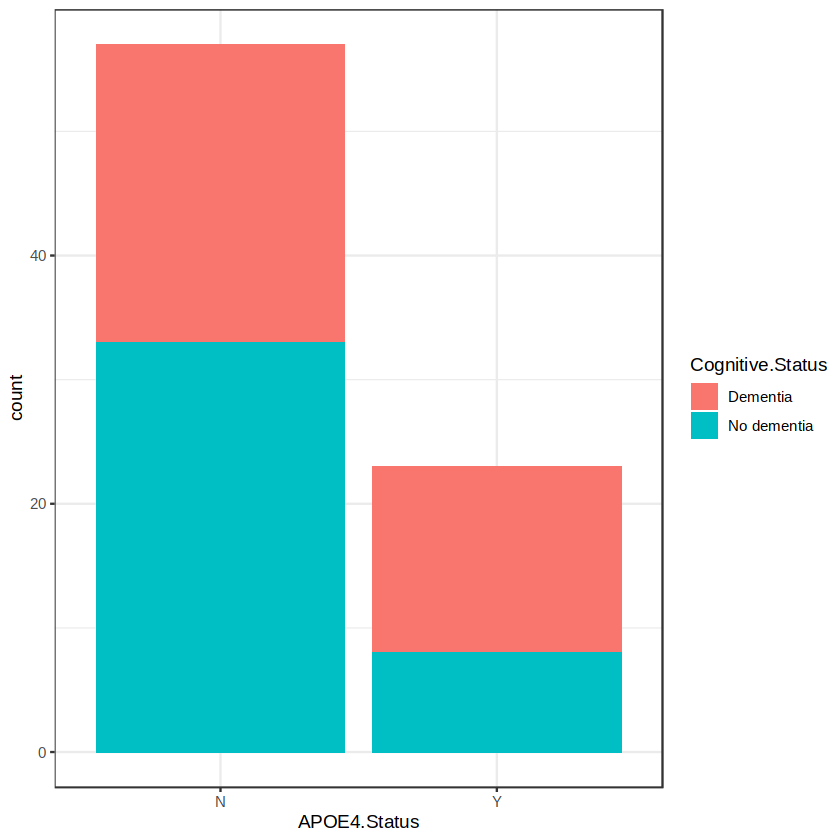

In [10]:
table(mts[!(missing.cognitive.status)]$APOE4.Status)
ggplot(mts[!(missing.cognitive.status)])+geom_bar(aes(x=APOE4.Status,fill=Cognitive.Status))+theme_bw( )+scale_fill_manual(values=c(scales::hue_pal()(2),'grey'))


In [11]:
### Age
The age covariates is not numerical because contain '90+' value, for people with more than 90yo. In order to conserved the numerical metrics, We create 2 age covariates: one 
with the `age_decade` ( each tranche of 10years), and `age_at_death_num` numerical covariates, where we consider '90+' having 91yo.

### Age
The age covariates is not numerical because contain '90+' value, for people with more than 90yo. In order to conserved the numerical metrics, We create 2 age covariates: one 
with the `age_decade` ( each tranche of 10years), and `age_at_death_num` numerical covariates, where we consider '90+' having 91yo.


Warning message in `[.data.table`(mts, !(missing.cognitive.status), `:=`(age_decade, :
“Coercing 'character' RHS to 'integer' to match the type of the target column (column 136 named 'age_decade').”


    
     Dementia No dementia
  60        2           0
  70        3           3
  80       12          15
  90       22          23

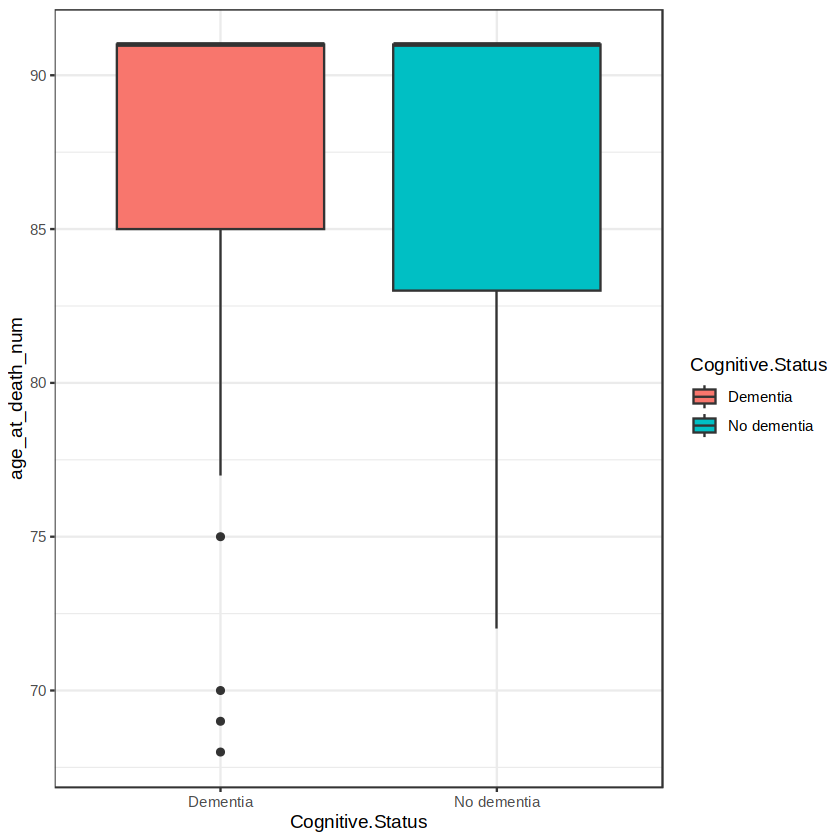

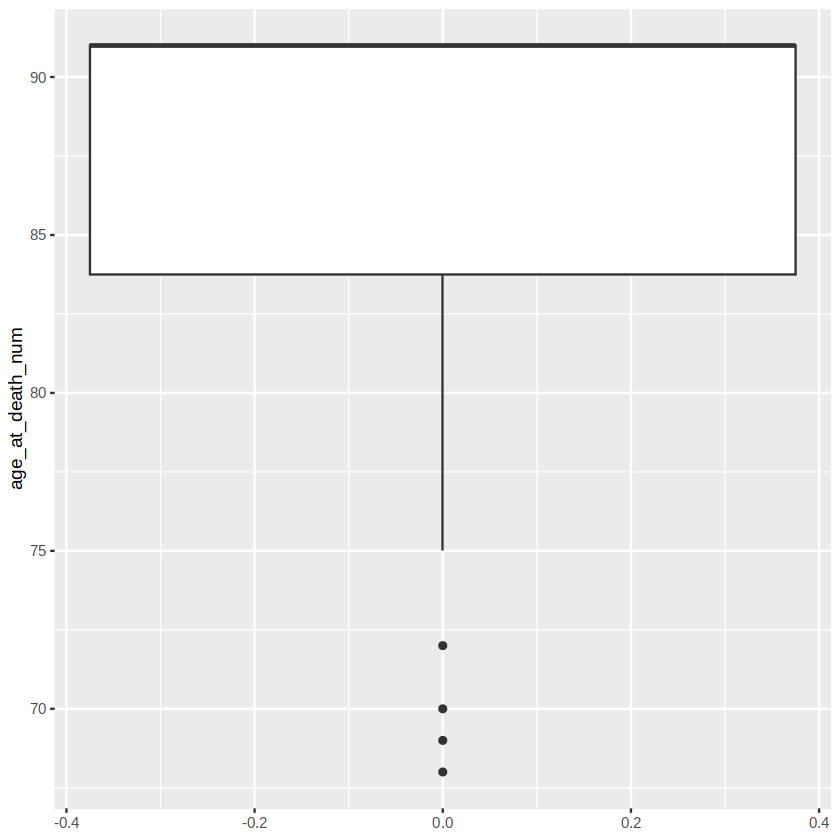

In [12]:
mts[!(missing.cognitive.status),age_decade:=paste0(str_extract(Age.at.Death,'^[1-9]'),'0')]
mts[!(missing.cognitive.status),age_at_death_num:=as.numeric(ifelse(Age.at.Death=='90+',91,Age.at.Death))]

table(mts[!(missing.cognitive.status)]$age_decade,mts[!(missing.cognitive.status)]$Cognitive.Status)
  #    Dementia No dementia
  # 60        2           0
  # 70        3           3
  # 80       12          15
  # 90       22          23

ggplot(mts[!(missing.cognitive.status)])+geom_boxplot(aes(x=Cognitive.Status,y=age_at_death_num,fill=Cognitive.Status))+theme_bw()
ggplot(mts[!(missing.cognitive.status)])+geom_boxplot(aes(y=age_at_death_num)) #ok

mts[,outlier.clinical.status:=missing.cognitive.status]


In [13]:
There is some outliers in Dementia people (younger than usual), but the difference with Control donors is small, so we did not flag them as outliers. 

There is some outliers in Dementia people (younger than usual), but the difference with Control donors is small, so we did not flag them as outliers. 


In [14]:
### PMI

### PMI


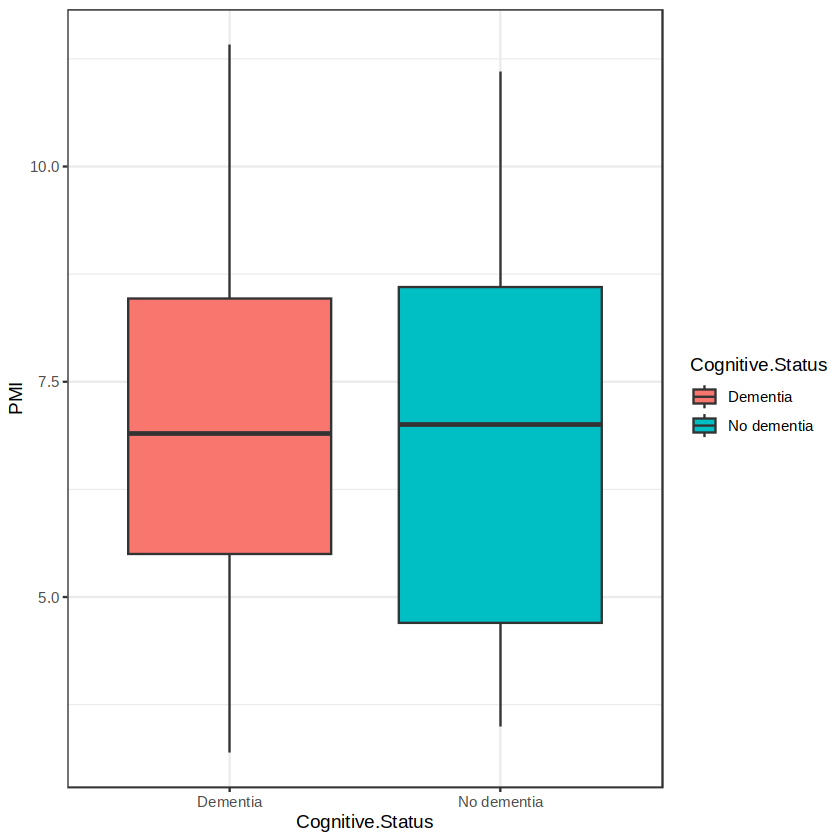

In [15]:
ggplot(mts[!(missing.cognitive.status)])+geom_boxplot(aes(x=Cognitive.Status,y=PMI,fill=Cognitive.Status))+theme_bw() #ok


In [16]:
No outlier in term of PMI

No outlier in term of PMI


In [17]:
### Ethnicity

### Ethnicity


In [18]:
The ethnicity have been stored has a binary variable (yes/no) for each each ethni, we then create a column grouping these different binary covariates

The ethnicity have been stored has a binary variable (yes/no) for each each ethni, we then create a column grouping these different binary covariates



  Checked Unchecked 
       77         3 

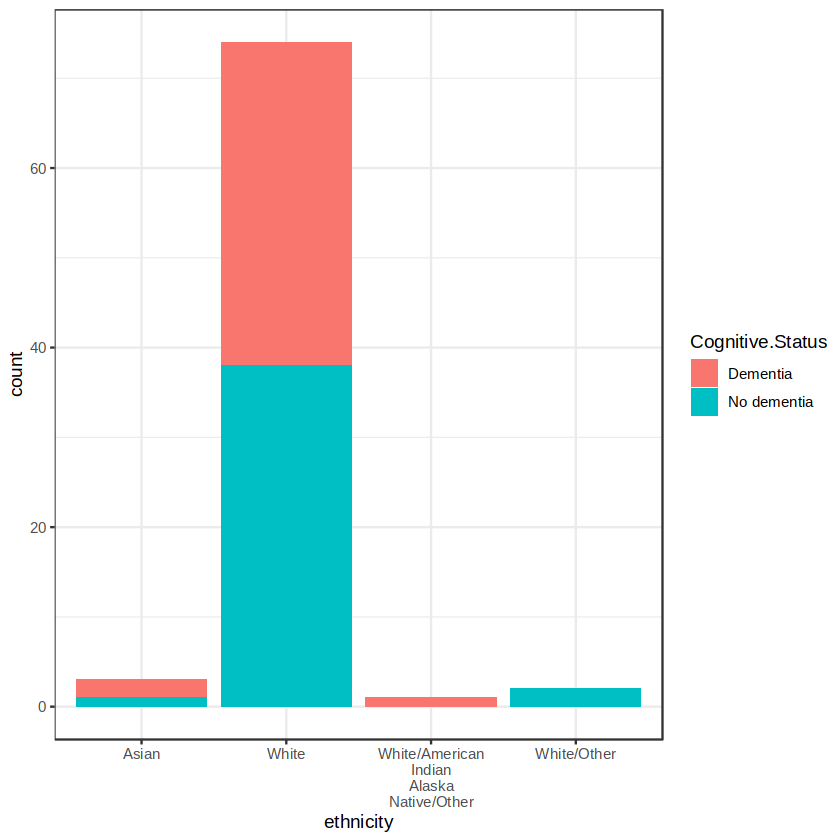

In [19]:
table(mts[!(missing.cognitive.status)]$Race..choice.White.)
  # Checked Unchecked 
  #      77         3 
races_cols<-colnames(mts)[str_detect(colnames(mts),'^Race')]
races<-str_remove(str_remove(races_cols,'Race..choice.'),'\\.$')
mts[!(missing.cognitive.status),ethnicity:=paste(races[sapply(.SD,function(x)x=='Checked')],collapse = '_'),by='Donor.ID',.SDcols=races_cols]
ggplot(mts[!(missing.cognitive.status)])+
  geom_bar(aes(x=ethnicity,fill=Cognitive.Status))+theme_bw() +
  scale_x_discrete(labels = function(x) str_wrap(str_replace_all(str_replace_all(x,'\\.',' '),'_','/'), width = 10))

In [20]:
Here we will flag as outliers Asian donors

Here we will flag as outliers Asian donors


In [21]:
mts[,outlier.ethnicity:=ethnicity=='Asian']

In [22]:
We have finish with the Clinical status analysis, we stored this outliers flag in the main metadata and switch to the molecular /Cellular quality check!

We have finish with the Clinical status analysis, we stored this outliers flag in the main metadata and switch to the molecular /Cellular quality check!


In [23]:
mts[,outlier.clinical.status:=missing.cognitive.status|outlier.ethnicity]

cat(nrow(mts[(outlier.clinical.status)]),' donors flag as outlier based on clinical status') #6

#add this information to the main metadata
mtd<-merge(mtd,mts[,.SD,.SDcols=c('Donor.ID',setdiff(colnames(mts),colnames(mtd)))])


6  donors flag as outlier based on clinical status

In [24]:
## Cellular/Molecular Traits QC

## Cellular/Molecular Traits QC


In [25]:
### %MT 

### %MT 


In [26]:
Because high number of molecules coming from mitochondrial genes is associated with poor quality cells/nuclei, we will see if there is some outlier based on this.  
We compute the average %mitochondria counts for each donor/sample. 
%mito is also cell type dependent, so we compute these metrics also at cell type level

Because high number of molecules coming from mitochondrial genes is associated with poor quality cells/nuclei, we will see if there is some outlier based on this.  
We compute the average %mitochondria counts for each donor/sample. 
%mito is also cell type dependent, so we compute these metrics also at cell type level


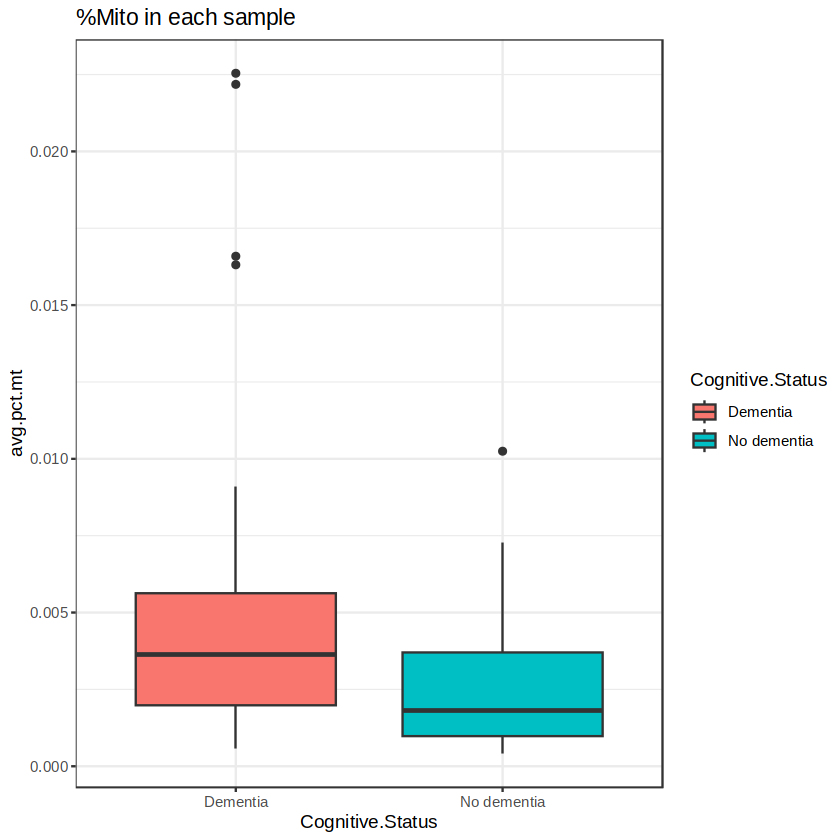

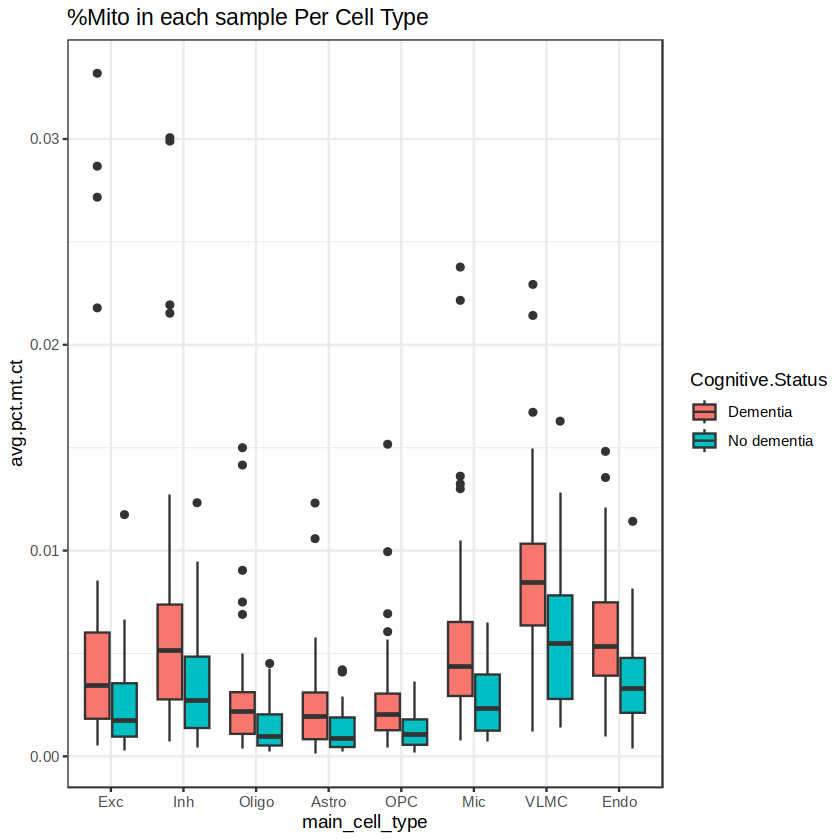

In [27]:
mtd[,avg.pct.mt:=mean(`Fraction.mitochondrial.UMIs`),by=c('Donor.ID')]
mtd[,avg.pct.mt.ct:=mean(`Fraction.mitochondrial.UMIs`),by=c('Donor.ID','main_cell_type')]

mtsc<-unique(mtd,by=c('Donor.ID','main_cell_type'))

ggplot(unique(mtsc[!(outlier.clinical.status)],by='Donor.ID'))+
  geom_boxplot(aes(x=Cognitive.Status,y=avg.pct.mt,fill=Cognitive.Status))+theme_bw()+ggtitle('%Mito in each sample')

ggplot(mtsc[!(outlier.clinical.status)])+
  geom_boxplot(aes(x=main_cell_type,y=avg.pct.mt.ct,fill=Cognitive.Status))+theme_bw()+ggtitle('%Mito in each sample Per Cell Type')


We can observed that %mito is higher in Inhibitory Neurons and Microglia, but also than high %mito is associated with dementia, so we won't used is as metrics to flag outliers

In [28]:
### Cellular Distribution analysis

### Cellular Distribution analysis


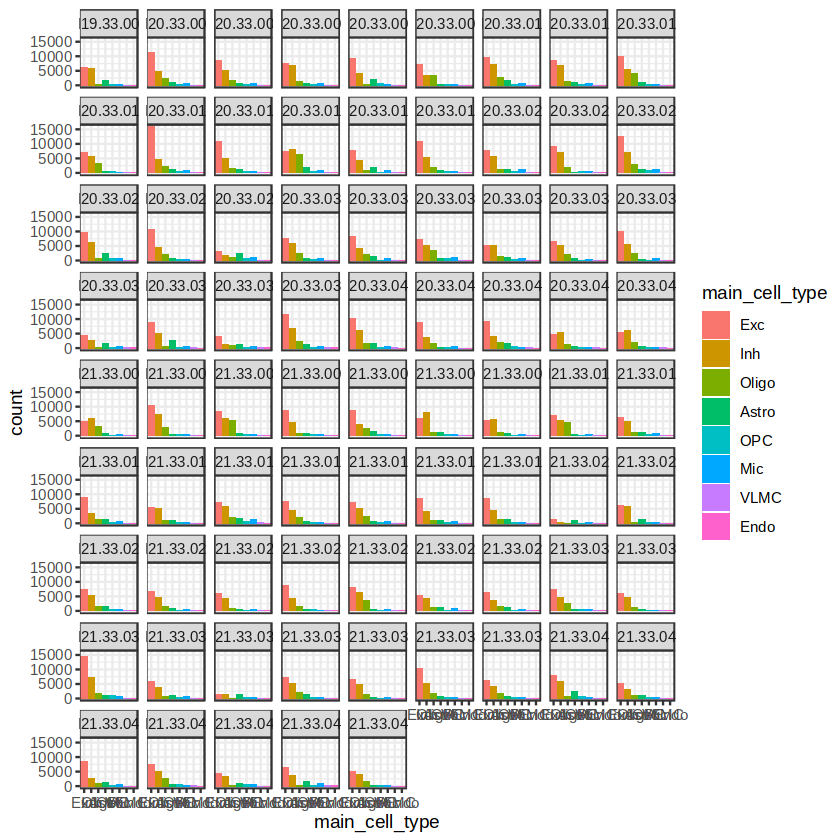

In [29]:
ggplot(mtd[!(outlier.clinical.status)])+
  geom_bar(aes(x=main_cell_type,fill=main_cell_type),position='dodge')+
  facet_wrap(~`Donor.ID`)+theme_bw()


In [30]:
We calculate the %of cell type by donors to flag is there is cell type distribution abnormalities in some donors

We calculate the %of cell type by donors to flag is there is cell type distribution abnormalities in some donors


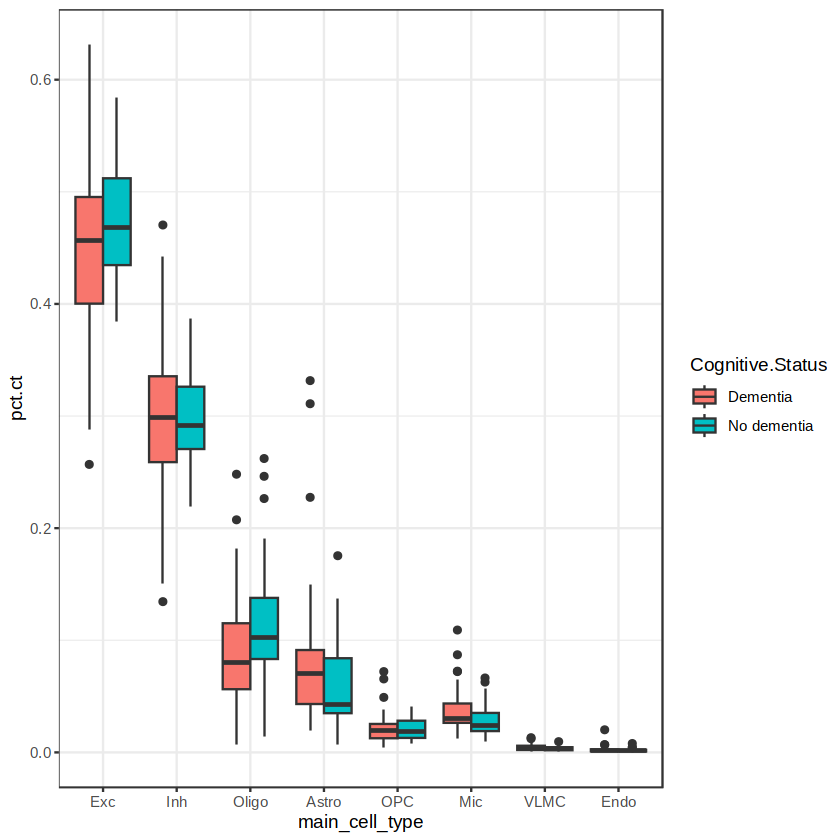

In [31]:
mtd[,n.cells:=.N,by=.(`Donor.ID`)]
mtd[,pct.ct:=.N/n.cells,by=.(`Donor.ID`,main_cell_type)]
mtd[,n.ct:=.N,by=.(`Donor.ID`,main_cell_type)]
mtd[,n.ct.all:=.N,by=.(main_cell_type)]
mtsc<-unique(mtd,by=c('Donor.ID','main_cell_type'))

ggplot(mtsc[!(outlier.clinical.status)])+
  geom_boxplot(aes(x=main_cell_type,y=pct.ct,fill=`Cognitive.Status`),position='dodge')+
  theme_bw()

In [32]:
It seems to have some samples with very high Astrocyte% and also others outliers, should we flag those samples?
#### Summarize Cell type proportions abnormalities at donor level
We reasoned that samples with very different Cell type composition from the others is associated with poor samples quality and should then be flag as outlier
To capture, the main divergence from the normal Cell type distribution, we compute the PCA of the % deviation from the interquartile range (IQR)

It seems to have some samples with very high Astrocyte% and also others outliers, should we flag those samples?
#### Summarize Cell type proportions abnormalities at donor level
We reasoned that samples with very different Cell type composition from the others is associated with poor samples quality and should then be flag as outlier
To capture, the main divergence from the normal Cell type distribution, we compute the PCA of the % deviation from the interquartile range (IQR)


removing 0 features (8remaining) because missing value or without variance



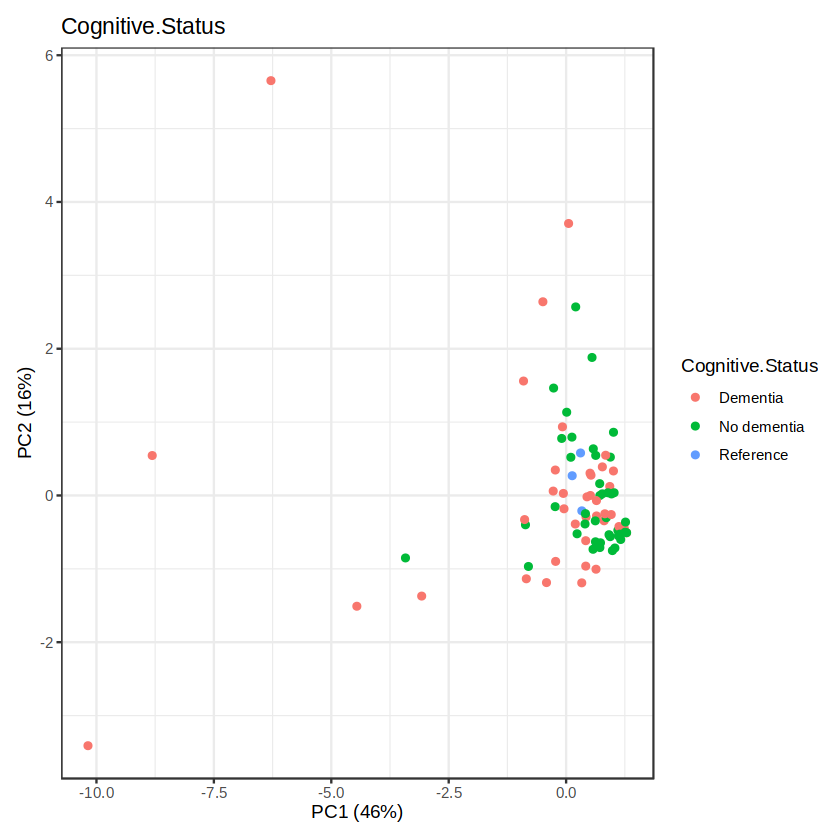

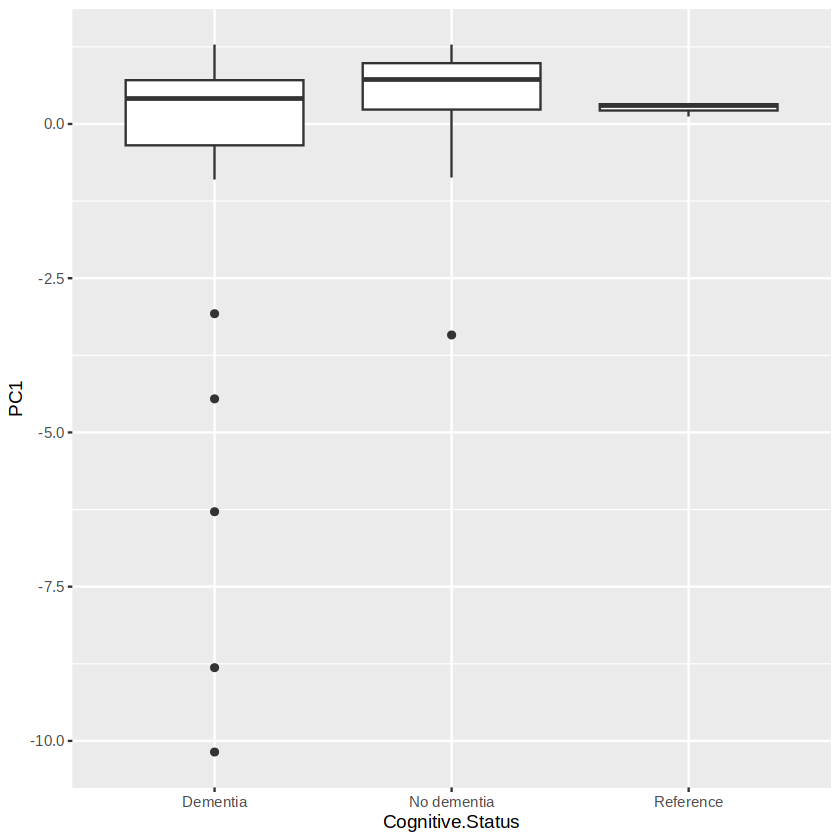

In [47]:
source('../../../utils/pca_utils.R')

mtsc[,pct.ct.q25:=quantile(pct.ct,0.25),by='main_cell_type']
mtsc[,pct.ct.q75:=quantile(pct.ct,0.75),by='main_cell_type']

mtsc[,pct.ct.IQR:=pct.ct.q75-pct.ct.q25]
mtsc[pct.ct<pct.ct.q25,pct.from.IQR:=(pct.ct.q25-pct.ct)/pct.ct.IQR]
mtsc[pct.ct>pct.ct.q75,pct.from.IQR:=(pct.ct-pct.ct.q75)/pct.ct.IQR]
mtsc[is.na(pct.from.IQR),pct.from.IQR:=0]
 #    Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
 # 0.000000  0.000000  0.003323  0.327975  0.362668 13.114971 

#create the matrix of Celltype% deviation and compute the PCA on it
iqr_skew_mat<-dcast(mtsc,Donor.ID~main_cell_type,value.var = 'pct.from.IQR')
iqr_skew_pca<-RunPca(t(data.frame(iqr_skew_mat,row.names = 'Donor.ID')),scale = T)

#merge the PCs with the sample level metadata and check PC1/PC2
#mts<-merge(mts,unique(mtsc[,.(Donor.ID,avg.pct.mt)])) #add to it also the avg pct mito compute before

mts_pca<-data.table(iqr_skew_pca$x,keep.rownames = 'Donor.ID')[mts,on='Donor.ID']
PcaPlot(iqr_skew_pca,mts,group.by ='Cognitive.Status',sample_col = 'Donor.ID')

ggplot(mts_pca)+geom_boxplot(aes(x=Cognitive.Status,y=PC1))


In [ ]:
No outlier in term of PMI

In [ ]:
The age covariates is not numerical because contain '90+' value, for people with more than 90yo. In order to conserved the numerical metrics, We create 2 age covariates from it 
age decade for each tranche of 10years, and age numerical, where we consider '90+' having 91yo.

In [48]:
We flag as outlier sample if  3 times away from the IQR of PC1


We flag as outlier sample if  3 times away from the IQR of PC1


Donor.ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PMI,⋯,batch_vendor_name,experiment_component_failed,alignment,missing.cognitive.status,outlier.clinical.status,ethnicity,outlier.ethnicity,outlier.cellular.status,outlier.cellprop,outlier
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
H20.33.028,-8.812763,0.5443391,-1.1790871,-2.5147564,-2.15923222,-0.15505400,-0.1799230,0.45716033,7.4,⋯,RTX-1058,FALSE,Cell Ranger 6,FALSE,FALSE,White,FALSE,TRUE,TRUE,TRUE
H20.33.036,-3.420257,-0.8515279,2.1168514,0.1642779,0.04366356,0.12341155,-0.4940044,-0.03721037,10.6,⋯,RTX-1019,FALSE,Cell Ranger 6,FALSE,FALSE,White,FALSE,TRUE,TRUE,TRUE
H20.33.038,-3.075313,-1.3713889,-1.0549397,-0.4723440,-0.25213011,-1.76150470,0.8912081,0.29286037,6.2,⋯,RTX-1050,FALSE,Cell Ranger 6,FALSE,FALSE,White,FALSE,TRUE,TRUE,TRUE
H21.33.020,-10.180477,-3.4104692,1.4856892,2.5249575,2.75449905,0.55972176,0.5780192,-0.38640255,10.8,⋯,RTX-1013,TRUE,Cell Ranger 6,FALSE,FALSE,White,FALSE,TRUE,TRUE,TRUE
H21.33.034,-6.284935,5.6536798,-0.2097781,-3.1178188,1.90579265,0.14199974,-0.5234200,0.18864721,10.8,⋯,RTX-1019,FALSE,Cell Ranger 6,FALSE,FALSE,White,FALSE,TRUE,TRUE,TRUE
H21.33.045,-4.455745,-1.5097870,-0.8375498,2.2742748,-2.48451987,0.03271725,-0.8960535,-0.30352492,4.0,⋯,RTX-1033,FALSE,Cell Ranger 6,FALSE,TRUE,Asian,TRUE,TRUE,TRUE,TRUE


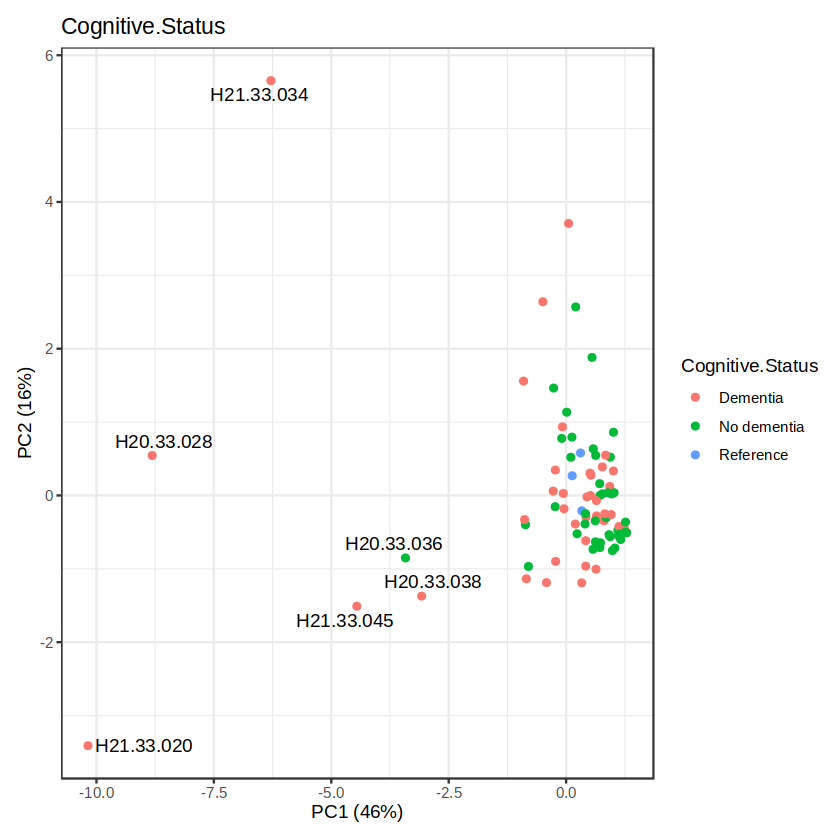

In [50]:
mts_pca[,outlier.cellprop:=PC1%in%boxplot.stats(PC1,coef=3)$out]
mts_pca[(outlier.cellprop)]

PcaPlot(iqr_skew_pca,mts,group.by ='Cognitive.Status',
        sample_col = 'Donor.ID',label = mts_pca$outlier.cellprop)


In [ ]:
There is some outliers in Dementia people (younger than usual), but the difference with to Control donors is small, so we did not flag them as outliers. 

In [51]:
These outliers are associated with high %mito, confirming than these are bad quality samples

These outliers are associated with high %mito


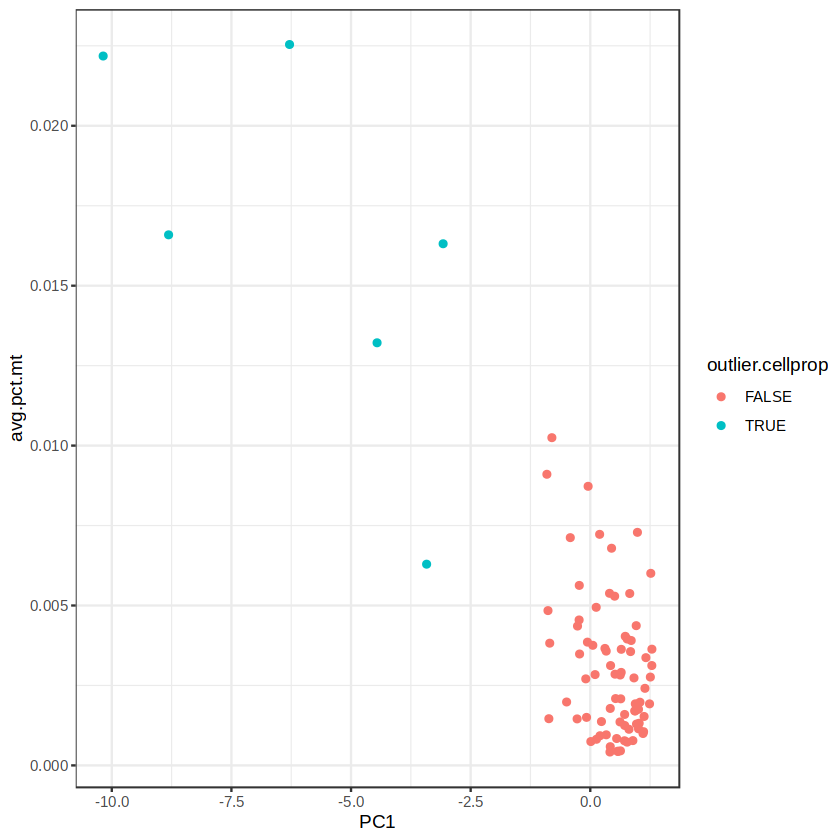

In [52]:
ggplot(mts_pca)+geom_point(aes(x=PC1,y=avg.pct.mt,col=outlier.cellprop))+theme_bw()



In [ ]:
### Study Sample quality (%mito and Cell Proportions abnormality)
Here we will compute statistics at cell type level to calculate both %mito and Cell proportions abnomralities which will point bad quality samples.

In [ ]:
mtd[,n.cells:=.N,by=.(`Donor.ID`)]
mtd[,pct.ct:=.N/n.cells,by=.(`Donor.ID`,main_cell_type)]
mtd[,n.ct:=.N,by=.(`Donor.ID`,main_cell_type)]
mtd[,n.ct.all:=.N,by=.(main_cell_type)]
mtsc<-unique(mtd,by=c('Donor.ID','main_cell_type'))

ggplot(mtsc[!(outlier.clinical.status)])+
  geom_boxplot(aes(x=main_cell_type,y=pct.ct,fill=`Cognitive.Status`),position='dodge')+
  theme_bw()


In [55]:
That's all!

We conserved these Celltype Composition abnormality metric in the metadata 


That's all!

We conserved these Celltype Composition abnormality metric in the metadata 


In [56]:
mts_pca[,cell_prop_dev_pc1:=PC1]

mts_pca[,outlier.cellular.status:=outlier.cellprop]
mts_pca[(outlier.cellular.status)]$Donor.ID

[1] "H20.33.028" "H20.33.036" "H20.33.038" "H21.33.020" "H21.33.034"
[6] "H21.33.045"

In [53]:
### Gather both Clinical and Molecular/Cellular Traits QC
We merge and save both cell level, cell type level and sample level metadata 

### Gather both Clinical and Molecular/Cellular Traits QC
We merge and save both cell level, cell type level and sample level metadata 


In [58]:

mtsc<-merge(mtsc,mts_pca[,.(Donor.ID,outlier.cellprop,cell_prop_dev_pc1,outlier.cellular.status)])

mtd<-merge(mtd,mts_pca[,.(Donor.ID,outlier.cellprop,cell_prop_dev_pc1,outlier.cellular.status)])


mtd[,outlier:=outlier.cellular.status|outlier.clinical.status]

mts<-unique(mtd,by=c('Donor.ID'))
tot.outliers<-mts[(outlier)]$Donor.ID
cat(length(tot.outliers),' total sample outliers flagged' ) #12/84



12  total sample outliers flagged

In [59]:
To save the metadata at each level, we remove the useless columns using the RemoveUselessColumns() function present in [r_utils.R](https://github.com/TCW-lab/alexandre-utils)

To save the metadata at each level, we remove the useless columns using the RemoveUselessColumns() function present in [r_utils.R](https://github.com/TCW-lab/alexandre-utils)


In [ ]:
#save 
fwrite(mtd,'outputs/01-SEAAD_data/DLPFC/all_final_RNAseq_nuclei_metadata.csv.gz')

mts<-RemoveUselessColumns(mts,key_cols=c('Donor.ID'),pattern_to_exclude = 'ATAC|Multiome|Doublet|Number.of|Genes.|Class|Subclass|Supertype|cell_type')
fwrite(mts,'outputs/01-SEAAD_data/DLPFC/all_final_RNAseq_nuclei_sample_level_metadata.csv.gz')


mtsc<-RemoveUselessColumns(mtsc,key_cols=c('Donor.ID','main_cell_type'),pattern_to_exclude = 'ATAC|Multiome|Doublet|Number.of|Genes.|Subclass|Supertype')
fwrite(mtsc,'outputs/01-SEAAD_data/DLPFC/all_final_RNAseq_nuclei_main_cell_type_level_metadata.csv.gz')


In [ ]:
ggplot(mtd[!(outlier.clinical.status)])+
  geom_bar(aes(x=main_cell_type,fill=main_cell_type),position='dodge')+
  facet_wrap(~`Donor.ID`)+theme_bw()


In [ ]:
# Others preprocessing 
In order than the data are ready to use, we also perform other preprocessing :
##  Generate the per cell type Seurat object. 
From the h5ad data, We generated 1 Seurat object for each cell_type (aka `Subclass` in original metadata annotation), containing all previously created metadata.
If for a cell type, the data size exceed the maximal allowed matrix size in seurat v4 (200k cells), we split the data according to the `Supertype` defined original metadata annotatio


In [64]:
unique(mtd[,.(main_cell_type,cell_type,Subclass,Supertype)][order(cell_type)])


main_cell_type,cell_type,Subclass,Supertype
<fct>,<chr>,<chr>,<chr>
Astro,Astrocyte,Astrocyte,Astro_2
Astro,Astrocyte,Astrocyte,Astro_5
Astro,Astrocyte,Astrocyte,Astro_4
Astro,Astrocyte,Astrocyte,Astro_1
Astro,Astrocyte,Astrocyte,Astro_3
Astro,Astrocyte,Astrocyte,Astro_6-SEAAD
Endo,Endothelial,Endothelial,Endo_2
Exc,Exc_L2/3 IT,L2/3 IT,L2/3 IT_8
Exc,Exc_L2/3 IT,L2/3 IT,L2/3 IT_3


In [ ]:
See [01Di-create_seurat_celltype.R](../scripts/01Di-create_seurat_celltype.R) for details of how 

In [80]:
## Create the pseudobulk matrix

## Create the pseudobulk matrix


In [66]:
We create a pseudobulk matrix (aggregates cell counts by sample) for each `cell_type`, and for each `main_cell_type`
As a minimal working example (MWE), it is perform like that for each cell type: 

We create a pseudobulk matrix (aggregates cell counts by sample) for each `cell_type`, and for each `main_cell_type`
As a minimal working example (MWE), it is perform like that: 


In [ ]:
library(Seurat)
astro<-readRDS('../outputs/01-SEAAD_data/DLPFC/Astrocyte.rds')
pseudo_mat<-AggregateExpression(astro,assays = 'RNA',slot = 'count',group.by = 'Donor.ID',
                    return.seurat = FALSE)
fwrite(data.table(pseudo_mat$RNA,keep.rownames = 'gene_id'),'outputs/01-SEAAD_data/DLPFC/Astrocyte_pseudobulk.csv.gz')



In [67]:
The script for all cell type and brain region are in ['scripts/01Dii-create_pseudobulk_cell_type.R']('../scripts/01Dii-create_pseudobulk_cell_type.R')

The script for all cell type and brain region are in ['scripts/01Dii-create_pseudobulk_cell_type.R']('../scripts/01Dii-create_pseudobulk_cell_type.R')


In [77]:
### merge the divided object into one pseudobulk
for each cell type divided into different object/rds file(because too large data),we aggregate expression into one
 #we thus create a data.table `pseudo_files_dt` saving these information

### merge the divided object into one pseudobulk
for each cell type divided into different object/rds file(because too large data),we aggregate expression into one
 #we thus create a data.table `pseudo_files_dt` saving these information


In [ ]:
region='DLPFC'
out1<-fp(out,region)
mtd<-fread(fp(out1,'all_final_RNAseq_nuclei_metadata.csv.gz'))

#to match with the rds object name, we create a column containing the original cell type name 
mtd[,original_cell_type_name:=str_remove(str_replace_all(cell_type,' ','_'),'^Inh_|Exc_')]
mtd[,original_cell_type_name:=str_replace_all(original_cell_type_name,'/','-')]
fwrite(mtd,fp(out1,'all_final_RNAseq_nuclei_metadata.csv.gz')) 
  
mtsc<-unique(mtd,by=c('Donor.ID','cell_type'))
  
pseudo_files<-list.files(out1,pattern = '\\_pseudobulk\\.csv\\.gz',full.names = T)
pseudo_files_dt<-data.table(file=pseudo_files,
                              original_cell_type_name=str_remove(basename(pseudo_files),'_pseudobulk\\.csv\\.gz'))
pseudo_files_dt[,original_cell_type_name:=str_remove(original_cell_type_name,'\\_set[0-9]+')]
  
  
pseudo_files_dt<-merge(pseudo_files_dt,unique(mtsc[,.(original_cell_type_name,cell_type,main_cell_type)]))
pseudo_files_dt[,n_file:=.N,by='cell_type']
  
for(ct in unique(pseudo_files_dt[n_file>1]$original_cell_type_name)){
    pseudo_list<-lapply(pseudo_files_dt[original_cell_type_name==ct]$file, function(f)fread(f))
    
    #lacking samples column
    samples<-Reduce(union,lapply(pseudo_list,colnames))
    pseudo_list<-lapply(pseudo_list,function(x){
      samples_lacking<-setdiff(samples,colnames(x))
      x[,(samples_lacking):=0]
    })
    
    #transform as matrix
    pseudo_list<-lapply(pseudo_list, function(x)as.matrix(data.frame(x,row.names = 'gene_id')))
    
    #aggregate count by sample / featute
    features<-rownames(pseudo_list[[1]])
    samples<-colnames(pseudo_list[[1]])
    
    pseudo_merge<-Reduce(`+`,lapply(pseudo_list,function(x)x[features,samples]))
    print(head(pseudo_merge[,1:10]))
    fwrite(data.table(pseudo_merge,keep.rownames = 'gene_id'),fp(out1,paste0(ct,'pseudobulk.csv.gz')))
    
  }
                                    
  
#we do not need anymore of the pseudobulk data from the divided cell type objects, so we remove them
system(paste('rm',paste(pseudo_files_dt[n_file>1]$file,collapse = ' ')))
  
  

In [78]:
###  Create metadata for each pseudobulk 
In addition to the clinical covariates, we also store in each cell type level metadata different QC metrics like the proportion of this cell type in the sample, the median UMIs count and median gene detectedm as well as average %mitochondrial count that we could used as covariated in our pseudobulk analysis.  
Importantly, we also flag here samples with **less than 50 cells** for this cell type, This is a flag that we should use to exclude sample with not enough cells to overcome drop out events.

###  Create metadata for each pseudobulk 
In addition to the clinical covariates, we also store in each cell type level metadata different QC metrics like the proportion of this cell type in the sample, the median UMIs count and median gene detectedm as well as average %mitochondrial count that we could used as covariated in our pseudobulk analysis.  
Importantly, we also flag here samples with **less than 50 cells** for this cell type, This is a flag that we should use to exclude sample with not enough cells to overcome drop out events.


In [ ]:
#save diverse cell type level info 
mtd[,tot.cells.donor:=.N,by=.(`Donor.ID`)]
mtd[,n.cells:=.N,by=.(`Donor.ID`,cell_type)]

mtd[,prop.cells:=n.cells/tot.cells.donor,by=.(`Donor.ID`,cell_type)]
mtd[,med.umis.per.cell:=median(Number.of.UMIs,na.rm = T),by=.(`Donor.ID`,cell_type)]
mtd[,med.genes.per.cell:=median(Genes.detected,na.rm = T),by=.(`Donor.ID`,cell_type)]
mtd[,avg.pct.mt.per.cell:=mean(`Fraction.mitochondrial.UMIs`),by=c('Donor.ID','cell_type')]
mtsc<-unique(mtd,by=c('Donor.ID','cell_type'))
  
#flag donors with not enough cells
mtd[,pass.threshold.n.cells:=n.cells>50]
mtd[,outlier.n.cells:=!pass.threshold.n.cells,by=c('Donor.ID','cell_type')]
  
mtscf<-RemoveUselessColumns(mtsc,key_cols=c('Donor.ID','cell_type'),pattern_to_exclude = 'ATAC|Multiome|Doublet|Number.of|Genes.')
  
fwrite(mtscf,fp(out1,'all_final_RNAseq_nuclei_cell_type_level_metadata.csv.gz'))


In [79]:
## Merge by main Cell type
We then aggregated the pseudobulk matrix of each cell type belonging to the same main cell type (e.g, we sum counts for all Excitatory neurons together)
  
We also create the metadata associated to it  similarly than for the more resolutive level.


## Merge by main Cell type
We then aggregated the pseudobulk matrix of each cell type belonging to the same main cell type (e.g, we sum counts for all Excitatory neurons together)
  
We also create the metadata associated to it  similarly than for the more resolutive level.


In [ ]:

 # merge by main_cell_type
out2<-fp(out1,'pseudobulk_main_cell_type')
dir.create(out2)
pseudo_files<-list.files(out1,pattern = '\\_pseudobulk\\.csv\\.gz',full.names = T)
to_merge<-data.table(file=pseudo_files,
                       original_cell_type_name=str_remove(basename(pseudo_files),'_pseudobulk\\.csv\\.gz'))
  
  
to_merge<-merge(to_merge,unique(mtsc[,.(original_cell_type_name,cell_type,main_cell_type)]))
  
for(ct in unique(to_merge$main_cell_type)){
    message(ct)
    pseudo_list<-lapply(to_merge[main_cell_type==ct]$file, function(f)fread(f))
    
    #lacking samples column
    samples<-Reduce(union,lapply(pseudo_list,colnames))
    pseudo_list<-lapply(pseudo_list,function(x){
      samples_lacking<-setdiff(samples,colnames(x))
      x[,(samples_lacking):=0]
    })
    
    #transform as matrix
    pseudo_list<-lapply(pseudo_list, function(x)as.matrix(data.frame(x,row.names = 'gene_id')))
    
    #aggregate count by sample / featute
    features<-rownames(pseudo_list[[1]])
    samples<-colnames(pseudo_list[[1]])
    
    pseudo_merge<-Reduce(`+`,lapply(pseudo_list,function(x)x[features,samples]))
    print(head(pseudo_merge[,1:10]))
    fwrite(data.table(pseudo_merge,keep.rownames = 'gene_id'),fp(out2,paste0(ct,'.csv.gz')))
    
    
    #4) create mtd for each pseudobulk main cell type 

    mtd[,tot.cells.donor:=.N,by=.(`Donor.ID`)]
    mtd[,n.cells:=.N,by=.(`Donor.ID`,main_cell_type)]
    
    mtd[,prop.cells:=n.cells/tot.cells.donor,by=.(`Donor.ID`,main_cell_type)]
    
    mtd[,med.umis.per.cell:=median(Number.of.UMIs,na.rm = T),by=.(`Donor.ID`,main_cell_type)]
    mtd[,med.genes.per.cell:=median(Genes.detected,na.rm = T),by=.(`Donor.ID`,main_cell_type)]
    
    mtd[,avg.pct.mt.per.cell:=mean(`Fraction.mitochondrial.UMIs`),by=c('Donor.ID','main_cell_type')]
    
    mtsc<-unique(mtd,by=c('Donor.ID','main_cell_type'))
    
    #flag donors with not enough cells
    mtd[,pass.threshold.n.cells:=n.cells>50,by=]
    mtd[,outlier.n.cells:=!pass.threshold.n.cells,by=c('Donor.ID','main_cell_type')]
    
    mtscf<-RemoveUselessColumns(mtsc,key_cols=c('Donor.ID','main_cell_type'),pattern_to_exclude = 'ATAC|Multiome|Doublet|Number.of|Genes.')
    
    
    fwrite(mtscf,fp(out2,'all_final_RNAseq_nuclei_main_cell_type_level_metadata.csv.gz'))
    
  }

In [81]:
We saved everything at the same place in `outputs/01-SEAAD_data/[BrainRegion]/pseudobulk_main_cell_type`


We saved everything at the same place in `outputs/01-SEAAD_data/[BrainRegion]/pseudobulk_main_cell_type`


In [82]:

# Cell Level QC

# Cell Level QC


Here, For each Cell type object prviousliy created, we flag as outliers nuclei:
- With nUMIs > 3*away of IQR
- With nGenes > 3*away of IQR
- With %MT > 5%

the script to do so is available in [01Diii-cell_level_QC.R](../scripts/01Diii-cell_level_QC.R)

Here an example for astrocyte DLPFC

In [87]:
### Flag cells with abnormal number of UMIsm and number of genes

### Flag cells with abnormal number of UMIsm and number of genes


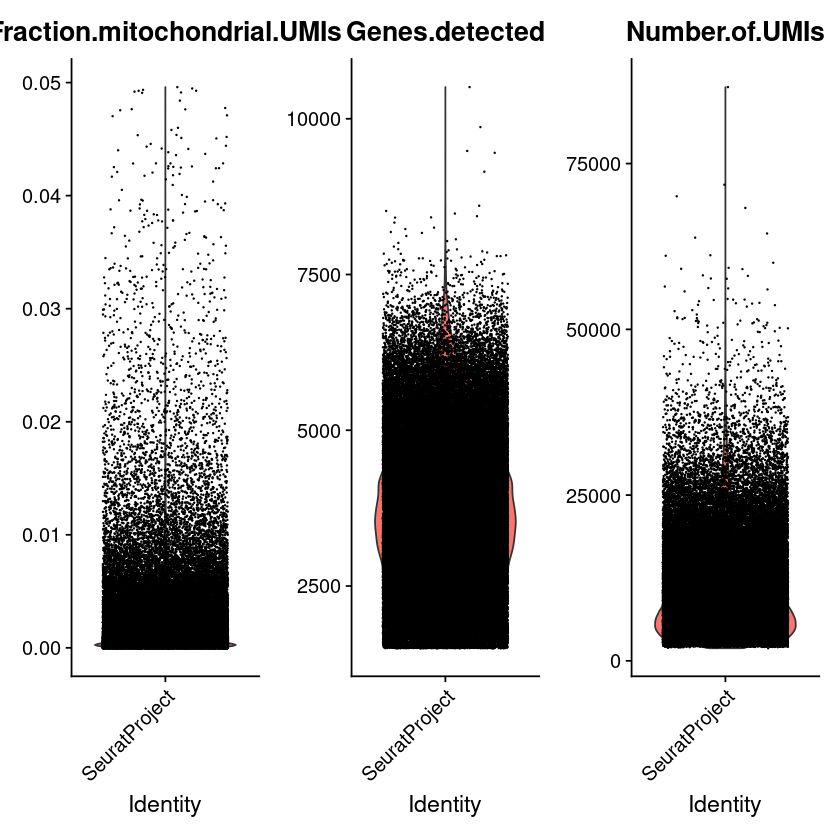

Warning message:
“Groups with fewer than two data points have been dropped.”


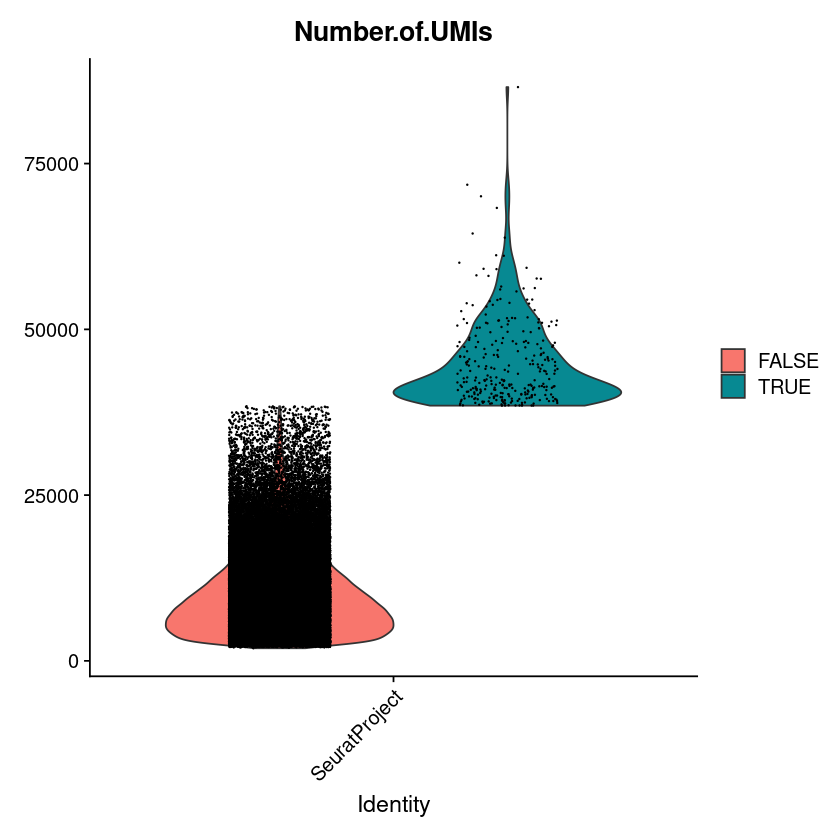

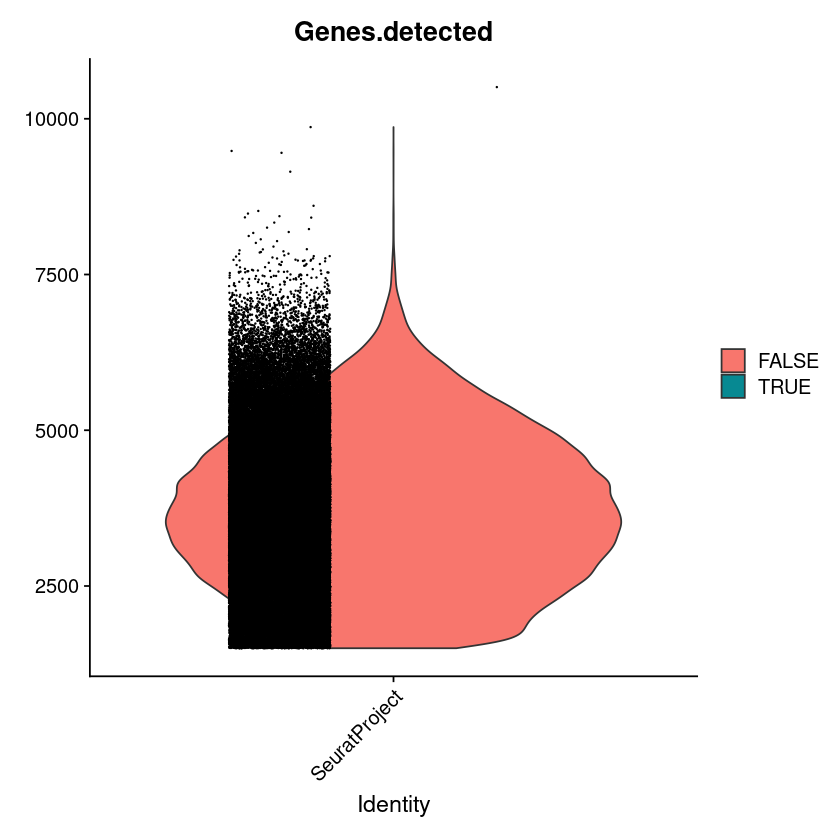

In [16]:
library(Seurat)
library(data.table)

astro<-readRDS('../outputs/01-SEAAD_data/DLPFC/Astrocyte.rds')
VlnPlot(astro,features =  c('Fraction.mitochondrial.UMIs','Genes.detected','Number.of.UMIs'))

boxres<-boxplot.stats(astro$Number.of.UMIs,coef = 3)
astro$UMIs.outlier<-colnames(astro)%in%names(boxres$out)
VlnPlot(astro,features =  'Number.of.UMIs',split.by = 'UMIs.outlier')
#VlnPlot(astro,features =  'Number.of.UMIs',split.by = 'UMIs.outlier',group.by = 'Donor.ID')

boxres<-boxplot.stats(astro$Genes.detected,coef = 3)
astro$Genes.outlier<-colnames(astro)%in%names(boxres$out)
VlnPlot(astro,features =  'Genes.detected',split.by = 'Genes.outlier')

#VlnPlot(astro,features =  'Genes.detected',split.by = 'Genes.outlier',group.by = 'Donor.ID')



### Flag nuclei with high mitochondrial count percentage
We cannot use MIQC for single nuc (see this issue https://github.com/TCW-lab/SingleCell_APOE44/issues/2) 
we will thus use classical outlier threshold to flag these cells 


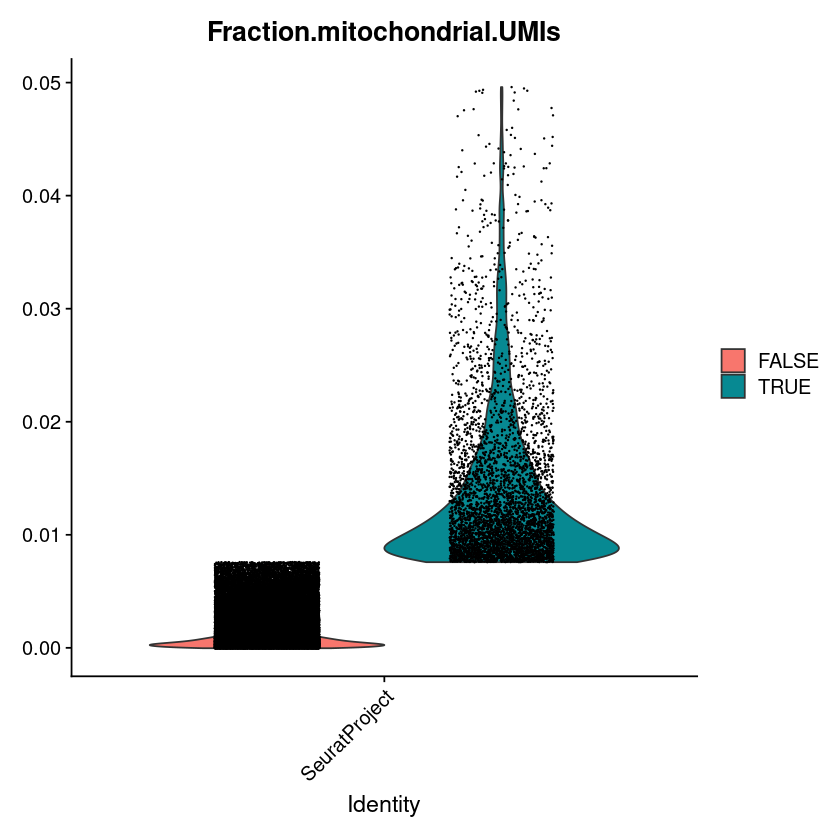

In [17]:
#percent.mt
#we cannot  use MIQC for scNuc https://github.com/TCW-lab/SingleCell_APOE44/issues/2

boxres<-boxplot.stats(astro$Fraction.mitochondrial.UMIs,coef = 3)
 
 
astro$Mito.high<-colnames(astro)%in%names(boxres$out)
VlnPlot(astro,features =  'Fraction.mitochondrial.UMIs',split.by = 'Mito.high')

#VlnPlot(astro,features =  'Fraction.mitochondrial.UMIs',split.by = 'Mito.high',group.by = 'Donor.ID')



As you can see, the 3*IQR threshold is too stringent for %mito, we will use only hard threshold of 5% (already done in SEA-AD)

In [18]:
#For scNuc, keep hardthreshold of 5% mito
astro$Mito.outlier<-astro$Fraction.mitochondrial.UMIs>0.05

#Final outlier is:
astro$donor.outlier<-astro$outlier #conserved donor outlier metadata compute in previous step
astro$cell.outlier<-astro$Genes.outlier|astro$UMIs.outlier|astro$Mito.outlier

astro$outlier<-astro$donor.outlier

message(round(sum(astro$donor.outlier)/nrow(astro),digits = 1),'% cells flagged as donors outliers')
message(round(sum(astro$cell.outlier)/nrow(astro),digits = 1),'% cells flagged as cells outliers' )

message('In total ',round(sum(astro$outlier)/nrow(astro),digits = 1),'% cells flagged as outliers')



0.4% cells flagged as donors outliers

0% cells flagged as cells outliers

In total 0.4% cells flagged as outliers



We then save this fully QC/flagged object

In [ ]:
#save the full object
saveRDS(astro,'../outputs/01-SEAAD_data/DLPFC/Astrocyte.rds')

## High quality small Seurat object creation
For convenience, we create for each cell type a smaller object containing only the 10% higher quality Donors and cells.
These could be use to test code/ analysis on smaller dataset and/or as reference for cell type re-annotation.

In [28]:
#create the QCed good quqlity ~10Kcell reduced object 
astro_qc<-astro[,!astro$outlier]
astro_qc #71k astrocytes after full QC

#get the top10% donors
good_qual_donors<-unique(astro_qc$Donor.ID[!astro_qc$outlier&
                                           astro_qc$avg.pct.mt<=quantile(astro_qc$avg.pct.mt,0.10)&
                                           astro_qc$cell_prop_dev_pc1<=quantile(astro_qc$cell_prop_dev_pc1,0.90)])
length(good_qual_donors)#13
celltype_qc_small<-subset(astro_qc,Donor.ID%in%good_qual_donors)

saveRDS(celltype_qc_small,file.path(out2,paste0(ct,'_qc_small.rds')))

mts<-unique(data.table(celltype_qc_small@meta.data),by=c('Donor.ID'))
table(mts[,.(Cognitive.Status,APOE4.Status)])

                APOE4.Status
Cognitive.Status  N  Y
     Dementia     0  1
     No dementia 11  1

These small objects of high quality 12 donors as well as QC figures have been saved in `outputs/01-SEAAD_data/[BrainRegion]/QC_small`